In [1]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv("placement.csv")

In [4]:
df.head()


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.shape

(100, 4)

## Steps
0. Preprocesssing + EDA + Feature Selection
1. Exract Input and Output Columns
2. Scale the values
3. Train test splits
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model



In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [7]:
df=df.iloc[:,1:]
df 

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


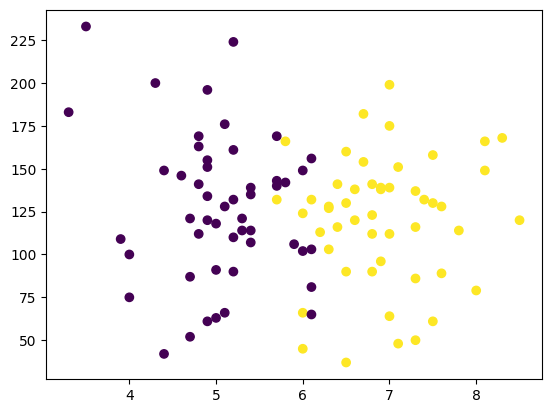

In [11]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [12]:
x=df.iloc[:,0:2]
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y=df.iloc[:,-1]
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
train_test_split(x,y,test_size=0.1)

[    cgpa     iq
 18   4.0  100.0
 5    7.1   48.0
 83   7.5  130.0
 44   7.5   61.0
 55   7.8  114.0
 ..   ...    ...
 82   6.5   37.0
 10   6.0   45.0
 72   7.3  116.0
 4    5.8  142.0
 43   6.8  141.0
 
 [90 rows x 2 columns],
     cgpa     iq
 62   6.0  102.0
 47   5.2  161.0
 27   6.0  124.0
 71   6.1  132.0
 17   3.3  183.0
 1    5.9  106.0
 68   4.0   75.0
 65   8.1  166.0
 57   6.5  130.0
 80   4.9  196.0,
 18    0
 5     1
 83    1
 44    1
 55    1
      ..
 82    1
 10    1
 72    1
 4     0
 43    1
 Name: placement, Length: 90, dtype: int64,
 62    0
 47    0
 27    1
 71    1
 17    0
 1     0
 68    0
 65    1
 57    1
 80    0
 Name: placement, dtype: int64]

In [17]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.1)

In [18]:
x_train

,cgpa,iq
14,6.1,103.0
73,4.9,61.0
9,5.1,66.0
45,6.0,66.0
97,6.7,182.0
...,...,...
26,7.0,199.0
21,7.1,151.0
90,7.3,86.0
1,5.9,106.0


In [19]:
y_train

14    0
73    0
9     0
45    1
97    1
     ..
26    1
21    1
90    1
1     0
81    0
Name: placement, Length: 90, dtype: int64

In [20]:
x_test

,cgpa,iq
22,4.9,120.0
76,4.9,155.0
78,6.1,81.0
43,6.8,141.0
19,5.2,132.0
25,5.0,91.0
41,5.4,114.0
59,4.8,112.0
4,5.8,142.0
48,6.6,138.0


In [21]:
y_test

22    0
76    0
78    0
43    1
19    0
25    0
41    0
59    0
4     0
48    1
Name: placement, dtype: int64

In [22]:
y_train

14    0
73    0
9     0
45    1
97    1
     ..
26    1
21    1
90    1
1     0
81    0
Name: placement, Length: 90, dtype: int64

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler=StandardScaler()

In [26]:
x_train=scaler.fit_transform(x_train)
x_train

array([[ 0.05144201, -0.50188541],
       [-0.97739821, -1.52075052],
       [-0.80592484, -1.39945705],
       [-0.03429467, -1.39945705],
       [ 0.56586212,  1.41455135],
       [-0.97739821,  1.75417305],
       [ 0.05144201,  0.78382533],
       [-1.14887158, -1.73907876],
       [ 0.22291538,  0.08032323],
       [ 0.65159881, -0.81724842],
       [-0.80592484,  0.10458192],
       [-0.29150473,  0.20161669],
       [ 1.68043903, -1.08409404],
       [ 1.2517556 ,  0.83234272],
       [ 0.65159881, -0.01671154],
       [ 1.08028223, -1.78759614],
       [ 1.76617571,  0.61401448],
       [-0.03429467,  0.00754715],
       [-0.20576804,  1.02641226],
       [ 0.82307218,  1.2447405 ],
       [-1.14887158, -0.06522893],
       [-0.29150473,  1.09918834],
       [-2.1777118 ,  2.6517447 ],
       [ 0.73733549,  0.34716885],
       [-0.72018816,  2.43341646],
       [-1.49181832,  1.85120783],
       [-1.23460827,  0.5412384 ],
       [-0.72018816, -0.81724842],
       [ 0.90880886,

In [27]:
x_test=scaler.transform(x_test)
x_test

array([[-0.97739821, -0.08948762],
       [-0.97739821,  0.75956664],
       [ 0.05144201, -1.03557666],
       [ 0.65159881,  0.41994493],
       [-0.72018816,  0.20161669],
       [-0.89166153, -0.79298972],
       [-0.54871479, -0.23503978],
       [-1.0631349 , -0.28355717],
       [-0.20576804,  0.44420363],
       [ 0.48012544,  0.34716885]])

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
clf=LogisticRegression()

In [30]:
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
y_pred=clf.predict(x_test)

In [32]:
y_test

22    0
76    0
78    0
43    1
19    0
25    0
41    0
59    0
4     0
48    1
Name: placement, dtype: int64

In [36]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9

<Axes: >

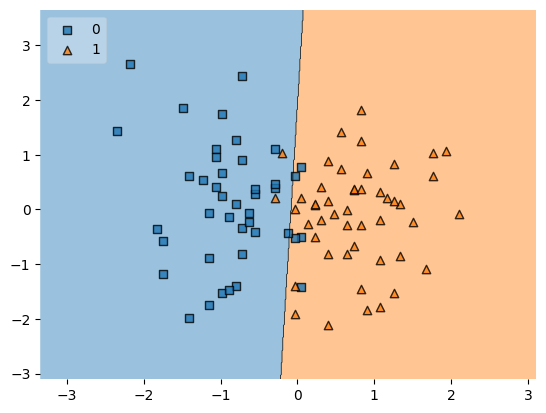

In [42]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [43]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))